Gamma Pulses

In [1]:
import pandas as pd
import csv

file_path = "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic scintillator 2/DataF_CH0@DT5730S_14333_TIFR_35VT_20OPPEA_30PPO_0.2MDAC_HV1050_G10_T200_SG50_LG500_PSD_AmBe_gamma_pulses.csv"

parsed_data = []
header = []
with open(file_path, 'r') as f:
    csv_reader = csv.reader(f, delimiter=';')
 
    # Read the header
    header = next(csv_reader)
 
    # Read the data rows
    for row in csv_reader:
        if not row:
            continue

        # The first 6 columns are fixed, the rest are part of SAMPLES
        fixed_cols = row[:6]
        samples = row[6:]
 
        # Create a dictionary for the row, joining samples into a list
        parsed_row = {

            'BOARD': fixed_cols[0],

            'CHANNEL': fixed_cols[1],

            'TIMETAG': fixed_cols[2],

            'ENERGY': fixed_cols[3],

            'ENERGYSHORT': fixed_cols[4],

            'FLAGS': fixed_cols[5],

            'SAMPLES': samples

        }
        parsed_data.append(parsed_row)
 
# Create the DataFrame

df = pd.DataFrame(parsed_data)
print("First 5 rows of the DataFrame:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df = pd.DataFrame(df['SAMPLES'].tolist())
samples_df = samples_df.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_1 = pd.concat([df.drop(columns=['SAMPLES']), samples_df], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_1.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG      | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,BOARD,CHANNEL,TIMETAG,ENERGY,ENERGYSHORT,FLAGS,t0,t1,t2,t3,...,t486,t487,t488,t489,t490,t491,t492,t493,t494,t495
0,0,0,20394348200,3108,2802,0x4000,13447,13446,13446,13448,...,13454,13452,13448,13447,13437,13441,13450,13450,13450,13444
1,0,0,125461458537,2630,2371,0x4000,13448,13449,13454,13449,...,13445,13450,13447,13449,13445,13447,13449,13443,13435,13449
2,0,0,318296155662,5448,4906,0x4000,13450,13444,13449,13452,...,13448,13445,13449,13447,13446,13439,13422,13419,13426,13427
3,0,0,598366310115,2244,2004,0x4000,13448,13443,13449,13450,...,13443,13445,13447,13444,13450,13448,13446,13447,13448,13453
4,0,0,658550373162,3229,2937,0x4000,13446,13445,13452,13444,...,13450,13453,13435,13448,13446,13448,13446,13438,13440,13449


In [2]:
# Select t-columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns

# Ensure numeric (important)
df_expanded_1[t_cols_1] = df_expanded_1[t_cols_1].apply(pd.to_numeric, errors='coerce')

# Compute row-wise max
df_expanded_1["t_max"] = df_expanded_1[t_cols_1].max(axis=1)

# Subtract max from each t-value
df_expanded_1[t_cols_1] = df_expanded_1[t_cols_1].sub(df_expanded_1["t_max"], axis=0).abs()
df_expanded_1[t_cols_1]

C:\Users\jayan\AppData\Local\Temp\ipykernel_49708\120410196.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_expanded_1["t_max"] = df_expanded_1[t_cols_1].max(axis=1)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t486,t487,t488,t489,t490,t491,t492,t493,t494,t495
0,10,11,11,9,9,9,10,2,9,10,...,3,5,9,10,20,16,7,7,7,13
1,7,6,1,6,6,2,7,6,8,6,...,10,5,8,6,10,8,6,12,20,6
2,3,9,4,1,4,2,3,10,4,7,...,5,8,4,6,7,14,31,34,27,26
3,7,12,6,5,6,4,2,8,6,4,...,12,10,8,11,5,7,9,8,7,2
4,10,11,4,12,17,8,10,5,7,8,...,6,3,21,8,10,8,10,18,16,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82124,5,7,7,5,7,8,2,12,6,6,...,4,1,5,8,10,7,0,4,14,16
82125,6,5,5,7,5,6,7,8,9,8,...,6,7,8,5,5,10,3,6,5,4
82126,7,9,6,5,13,8,4,5,10,6,...,4,6,3,2,6,6,7,10,9,9
82127,6,11,8,12,13,11,9,8,10,10,...,8,2,14,9,11,11,10,13,8,12


In [3]:
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0)
mean_waveform_1

t0       6.856409
t1       6.858174
t2       6.852038
t3       6.849980
t4       6.855057
          ...    
t491    11.802287
t492    11.794056
t493    11.783804
t494    11.764152
t495    11.780467
Length: 496, dtype: float64

497
496


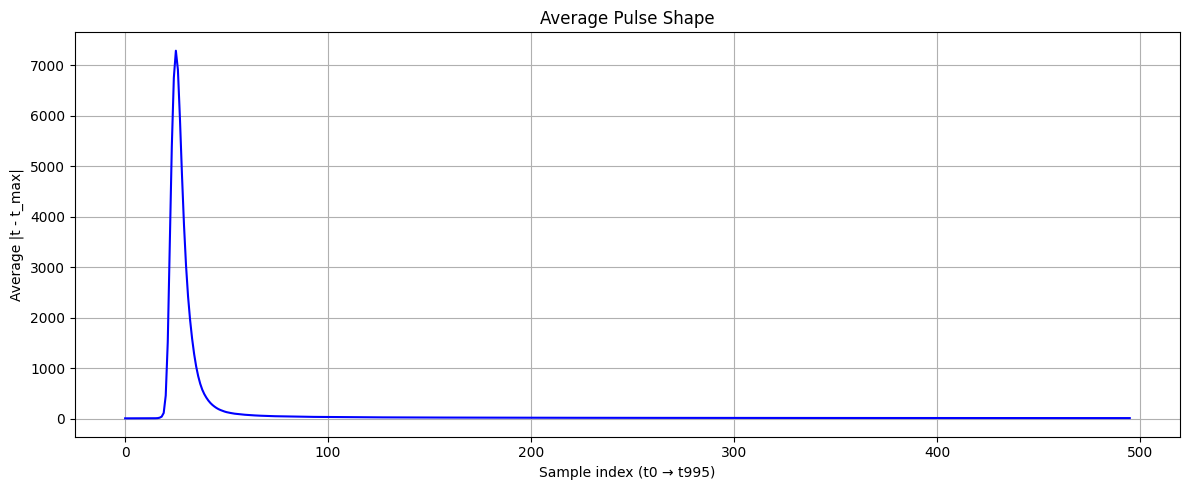

In [4]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns
print(len(t_cols_1))
# Compute column-wise mean
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0).iloc[:-1]
print(len(mean_waveform_1))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(t_cols_1)-1), mean_waveform_1, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import csv

# List of file paths
file_paths = [
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic scintillator 2/DataF_CH0@DT5730S_14333_TIFR_35VT_20OPPEA_30PPO_0.2MDAC_HV1050_G10_T200_SG50_LG500_PSD_AmBe_neutron_pulses-1.csv",
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic scintillator 2/DataF_CH0@DT5730S_14333_TIFR_35VT_20OPPEA_30PPO_0.2MDAC_HV1050_G10_T200_SG50_LG500_PSD_AmBe_neutron_pulses-2.csv"
]

parsed_data = []

# Loop through all files
for file_path in file_paths:
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')

        # Read header (skip, assuming all files have same header)
        header = next(csv_reader)

        # Read data rows
        for row in csv_reader:
            if not row:
                continue

            # First 6 columns fixed, rest are SAMPLES
            fixed_cols = row[:6]
            samples = row[6:]

            parsed_row = {
                'BOARD': fixed_cols[0],
                'CHANNEL': fixed_cols[1],
                'TIMETAG': fixed_cols[2],
                'ENERGY': fixed_cols[3],
                'ENERGYSHORT': fixed_cols[4],
                'FLAGS': fixed_cols[5],
                'SAMPLES': samples
            }
            parsed_data.append(parsed_row)

# Create initial DataFrame
df_2 = pd.DataFrame(parsed_data)

print("First 5 rows of the DataFrame:")
print(df_2.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df = pd.DataFrame(df_2['SAMPLES'].tolist())
samples_df = samples_df.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_2 = pd.concat([df_2.drop(columns=['SAMPLES']), samples_df], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_2.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG      | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,BOARD,CHANNEL,TIMETAG,ENERGY,ENERGYSHORT,FLAGS,t0,t1,t2,t3,...,t486,t487,t488,t489,t490,t491,t492,t493,t494,t495
0,0,0,13974798074,4440,3527,0x4000,13446,13446,13449,13443,...,13415,13430,13442,13442,13434,13437,13437,13437,13440,13436
1,0,0,161825101835,3154,2487,0x4000,13451,13446,13449,13447,...,13424,13429,13437,13424,13420,13421,13438,13437,13438,13442
2,0,0,457724708369,2045,1561,0x4000,13447,13450,13451,13446,...,13445,13448,13446,13449,13449,13449,13448,13447,13443,13447
3,0,0,542873364346,3488,2737,0x4000,13452,13445,13445,13449,...,13431,13431,13424,13425,13430,13444,13420,13433,13422,13432
4,0,0,629652732420,2806,2247,0x4000,13445,13444,13446,13445,...,13435,13427,13431,13428,13438,13435,13426,13420,13440,13444


In [6]:
# Select t-columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns

# Ensure numeric (important)
df_expanded_2[t_cols_2] = df_expanded_2[t_cols_2].apply(pd.to_numeric, errors='coerce')

# Compute row-wise max
df_expanded_2["t_max"] = df_expanded_2[t_cols_2].max(axis=1)

# Subtract max from each t-value
df_expanded_2[t_cols_2] = df_expanded_2[t_cols_2].sub(df_expanded_2["t_max"], axis=0).abs()
df_expanded_2[t_cols_2]

C:\Users\jayan\AppData\Local\Temp\ipykernel_49708\1722737464.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_expanded_2["t_max"] = df_expanded_2[t_cols_2].max(axis=1)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t486,t487,t488,t489,t490,t491,t492,t493,t494,t495
0,6,6,3,9,4,9,6,1,0,5,...,37,22,10,10,18,15,15,15,12,16
1,1,6,3,5,6,3,4,4,1,7,...,28,23,15,28,32,31,14,15,14,10
2,7,4,3,8,8,7,8,7,9,13,...,9,6,8,5,5,5,6,7,11,7
3,0,7,7,3,2,4,11,5,3,5,...,21,21,28,27,22,8,32,19,30,20
4,6,7,5,6,5,7,4,2,9,6,...,16,24,20,23,13,16,25,31,11,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72056,4,4,5,5,7,5,7,6,5,3,...,8,7,6,6,13,19,2,7,3,4
72057,7,10,9,2,5,9,7,5,6,6,...,24,13,6,15,30,8,11,5,12,12
72058,10,9,3,5,6,7,8,5,0,2,...,8,12,2,6,11,20,14,13,6,9
72059,3,7,6,7,3,7,8,10,4,10,...,7,0,9,1,6,9,8,24,19,10


In [7]:
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0)
mean_waveform_2

t0       5.615021
t1       5.616714
t2       5.602115
t3       5.600103
t4       5.603003
          ...    
t491    17.152163
t492    17.129696
t493    17.122535
t494    17.065209
t495    17.046572
Length: 496, dtype: float64

497
496


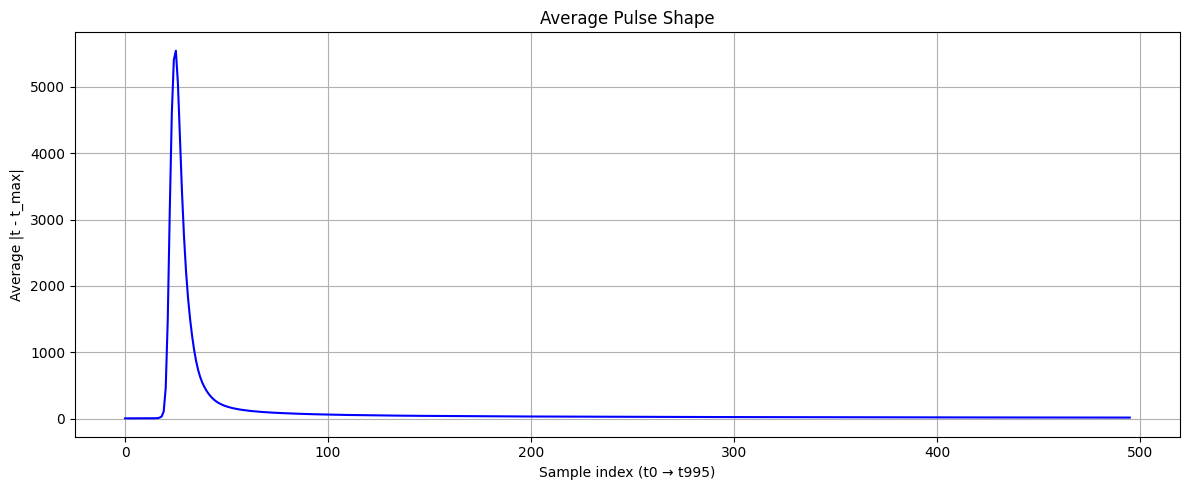

In [8]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns
print(len(t_cols_2))
# Compute column-wise mean
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0).iloc[:-1]
print(len(mean_waveform_2))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(t_cols_2)-1), mean_waveform_2, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


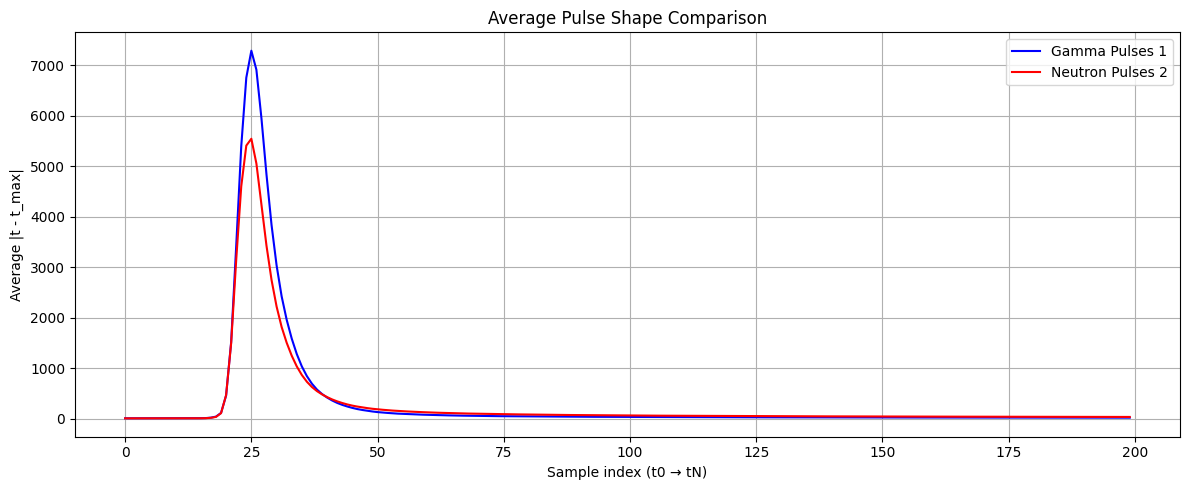

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

# Select waveform columns
t_cols_1 = df_expanded_1.filter(regex=r'^t').columns
t_cols_2 = df_expanded_2.filter(regex=r'^t').columns

# Compute column-wise mean (drop last column if needed) Averaged
mean_waveform_1 = df_expanded_1[t_cols_1].mean(axis=0).iloc[:-1]
mean_waveform_2 = df_expanded_2[t_cols_2].mean(axis=0).iloc[:-1]


mean_waveform_1_norm = (mean_waveform_1 -mean_waveform_1.min()) / (mean_waveform_1.max() - mean_waveform_1.min())
mean_waveform_2_norm = (mean_waveform_2 -mean_waveform_2.min()) / (mean_waveform_2.max() - mean_waveform_2.min())

df_1_norm = df_expanded_1[t_cols_1].sub(
    df_expanded_1[t_cols_1].min(axis=1), axis=0
).div(
    df_expanded_1[t_cols_1].max(axis=1) - df_expanded_1[t_cols_1].min(axis=1),
    axis=0
)

df_2_norm = df_expanded_2[t_cols_2].sub(
    df_expanded_2[t_cols_2].min(axis=1), axis=0
).div(
    df_expanded_2[t_cols_2].max(axis=1) - df_expanded_2[t_cols_2].min(axis=1),
    axis=0
)

# Create x-axis (sample indices)
x1 = range(len(mean_waveform_1))
x2 = range(len(mean_waveform_2))

# Plot both on same figure
x = range(200)

plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_1[0:200], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_2[0:200], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Averaged plots_Scintillator_2.png", dpi=300)  # Save as PNG with high resolution



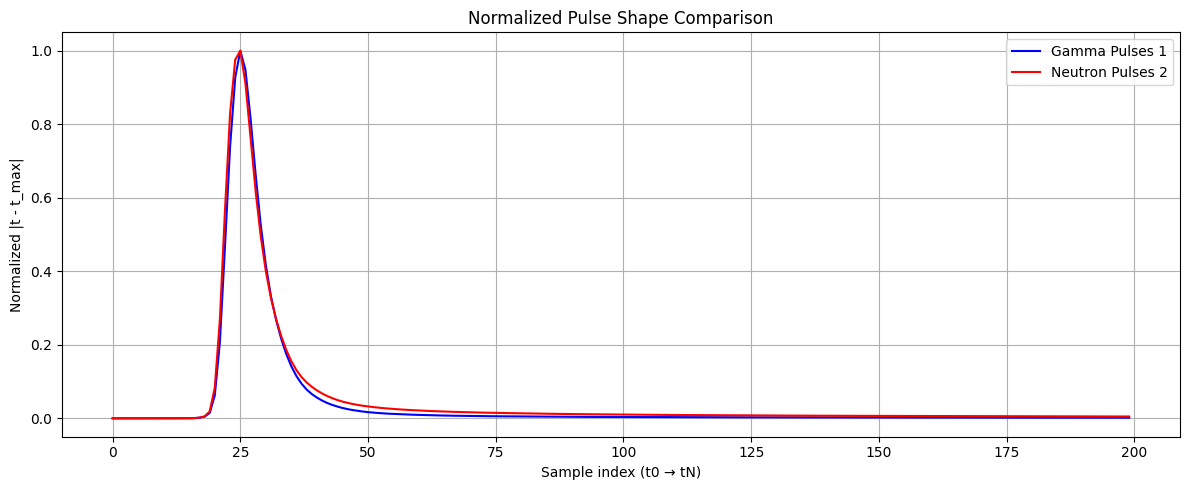

<Figure size 640x480 with 0 Axes>

In [13]:
# normalized
x = range(200)
plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_1_norm[0:200], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_2_norm[0:200], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Normalized |t - t_max|")
plt.title("Normalized Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Normalized plots_Scintillator_2.png", dpi=300)  # Save as PNG with high resolution


2.267579980994615
3.0122502172024324
Split @ 25: Accuracy = 0.5163
Confusion Matrix:
 [[13481  2945]
 [11972  2440]]
0.4171932957823874
0.5938772692759026
Split @ 30: Accuracy = 0.9058
Confusion Matrix:
 [[14884  1542]
 [ 1364 13048]]
0.1691222304074347
0.2665514782513301
Split @ 35: Accuracy = 0.9983
Confusion Matrix:
 [[16400    26]
 [   27 14385]]
0.09329129351915637
0.16884333080232855
Split @ 40: Accuracy = 0.9994
Confusion Matrix:
 [[16414    12]
 [    6 14406]]
0.07212825109777327
0.12376201484365501
Split @ 45: Accuracy = 0.9993
Confusion Matrix:
 [[16412    14]
 [    7 14405]]
0.057645973240375244
0.09777027669487502
Split @ 50: Accuracy = 0.9986
Confusion Matrix:
 [[16405    21]
 [   23 14389]]
0.0486416427355206
0.08584528568069603
Split @ 55: Accuracy = 0.9973
Confusion Matrix:
 [[16390    36]
 [   48 14364]]
0.03785401680164996
0.07218146359583955
Split @ 60: Accuracy = 0.9950
Confusion Matrix:
 [[16374    52]
 [  103 14309]]
0.03214267847316021
0.06604339796860573
Split @

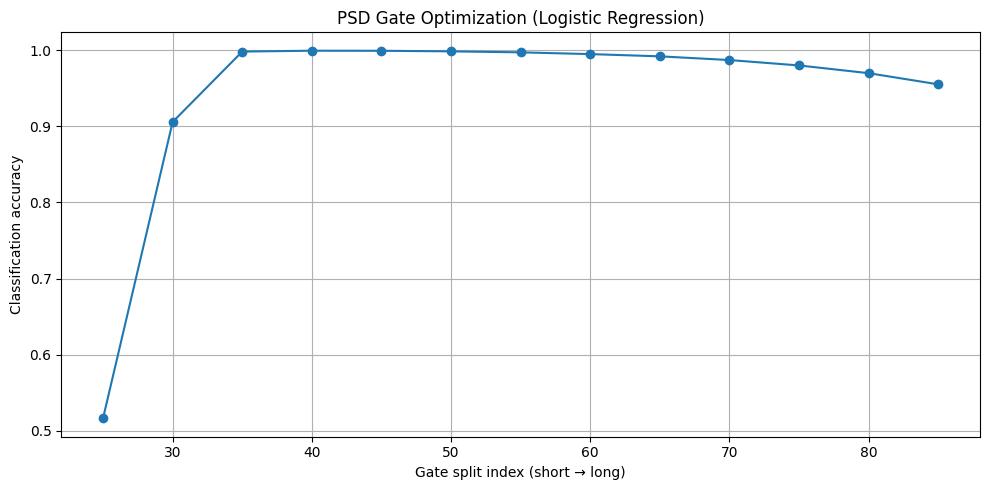

In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
# -------------------------------
# Gate sweep parameters
# -------------------------------
short_start = 20
long_end = 105
splits = range(25, 86, 5)   # 50, 55, 60, ..., 100

accuracies = []
conf_matrices = []
split_record = []

# -------------------------------
# Loop over split positions
# -------------------------------
for split in splits:
    # ---- Gamma ratios ----
    gamma_short = df_1_norm.iloc[:, short_start:split].sum(axis=1)
    gamma_long  = df_1_norm.iloc[:, split:long_end].sum(axis=1)
    gamma_ratio = 1/(gamma_short / gamma_long)
    print(gamma_ratio[1])
    # ---- Neutron ratios ----
    neutron_short = df_2_norm.iloc[:, short_start:split].sum(axis=1)
    neutron_long  = df_2_norm.iloc[:, split:long_end].sum(axis=1)
    neutron_ratio = 1/(neutron_short / neutron_long)
    print(neutron_ratio[1])

    # ---- Dataset ----
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])

    # ---- Train / test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # ---- Logistic Regression ----
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    # ---- Accuracy ----
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    split_record.append(split)

best_idx = np.argmax(accuracies)


print(best_idx)

# -------------------------------
# Plot accuracy vs gate split
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(splits, accuracies, marker='o')
plt.xlabel("Gate split index (short → long)")
plt.ylabel("Classification accuracy")
plt.title("PSD Gate Optimization (Logistic Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()
